In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Employee_Attrition.csv")

In [3]:
df.shape

(1000, 10)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Employee_ID         1000 non-null   str  
 1   Age                 1000 non-null   int64
 2   Gender              1000 non-null   str  
 3   Department          1000 non-null   str  
 4   Experience_Years    1000 non-null   int64
 5   Monthly_Salary      1000 non-null   int64
 6   Performance_Rating  1000 non-null   int64
 7   Work_Life_Balance   1000 non-null   str  
 8   Job_Satisfaction    1000 non-null   int64
 9   Attrition_Status    1000 non-null   str  
dtypes: int64(5), str(5)
memory usage: 78.3 KB


In [5]:
# Count employees by attrition status
total_attrition = df.groupby("Attrition_Status")["Employee_ID"].count()

# Calculate percentage
cat_pct = (total_attrition / total_attrition.sum()) * 100

# Round and display
print(cat_pct.round(2).astype(str) + "%")


Attrition_Status
No     71.6%
Yes    28.4%
Name: Employee_ID, dtype: str


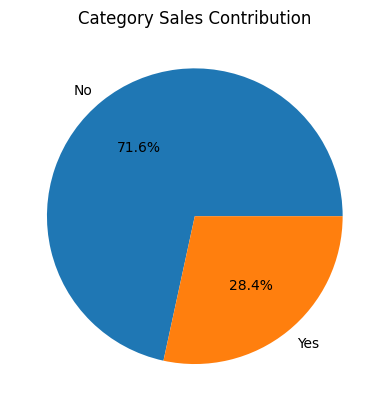

In [6]:
plt.pie(total_attrition, labels=total_attrition.index, autopct='%1.1f%%')
plt.title('Category Sales Contribution')
plt.show()

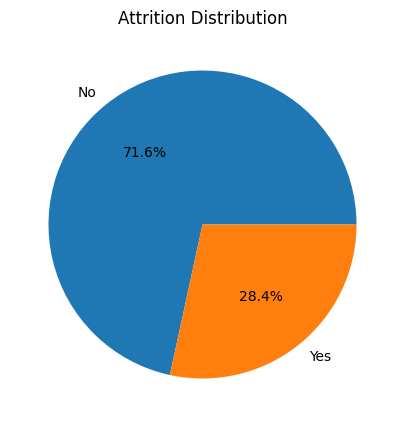

In [7]:
counts = df['Attrition_Status'].value_counts()
plt.figure(figsize=(6, 5))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title('Attrition Distribution')
plt.show()

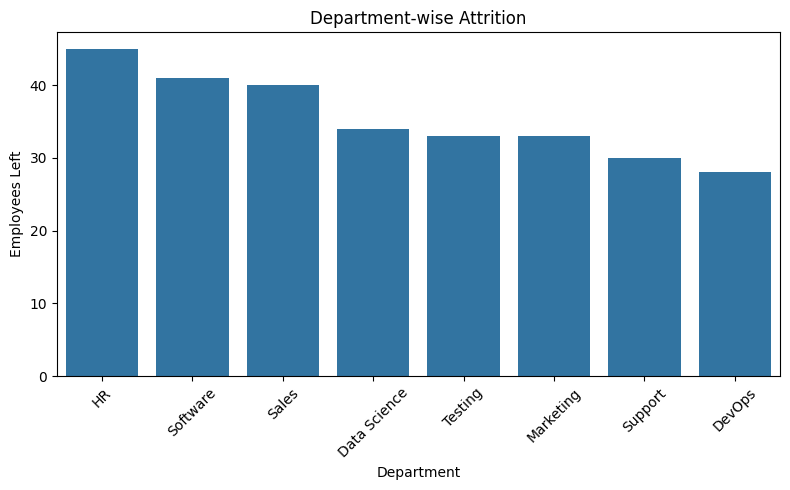

In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df[df['Attrition_Status'] == 'Yes']['Department'].value_counts().index,
            y=df[df['Attrition_Status'] == 'Yes']['Department'].value_counts().values)
plt.title('Department-wise Attrition')
plt.xlabel('Department')
plt.ylabel('Employees Left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

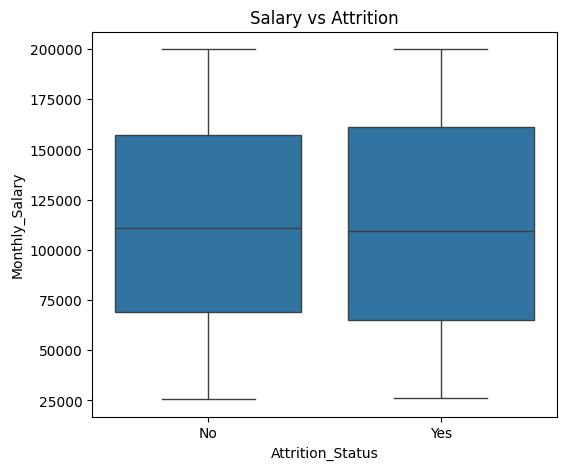

In [9]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Attrition_Status', y='Monthly_Salary', data=df)
plt.title('Salary vs Attrition')
plt.show()

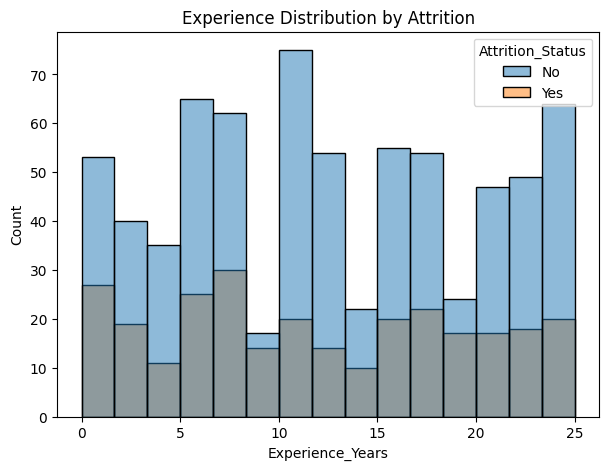

In [10]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x='Experience_Years', hue='Attrition_Status', bins=15)
plt.title('Experience Distribution by Attrition')
plt.show()

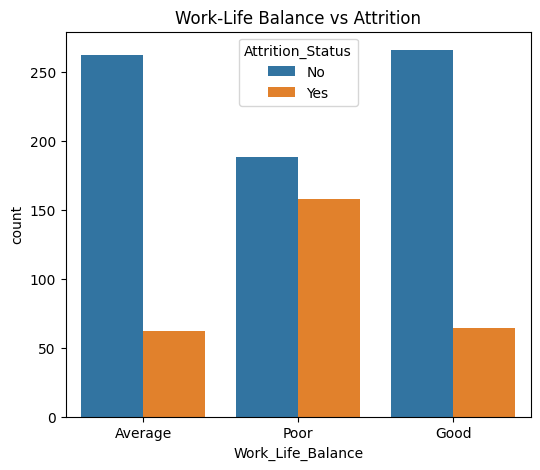

In [11]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Work_Life_Balance', hue='Attrition_Status', data=df)
plt.title('Work-Life Balance vs Attrition')
plt.show()

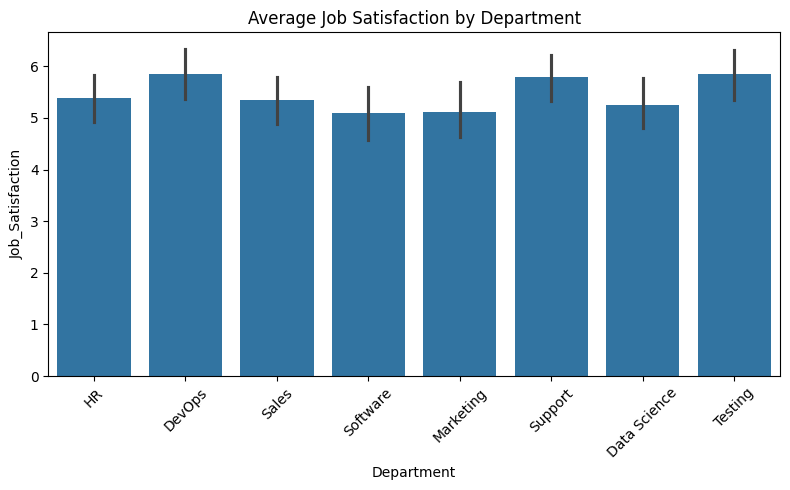

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Department', y='Job_Satisfaction', data=df)
plt.title('Average Job Satisfaction by Department')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

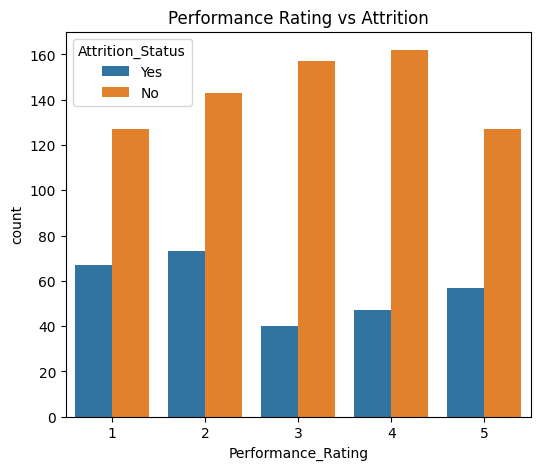

In [14]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Performance_Rating', hue='Attrition_Status', data=df)
plt.title('Performance Rating vs Attrition')
plt.show()

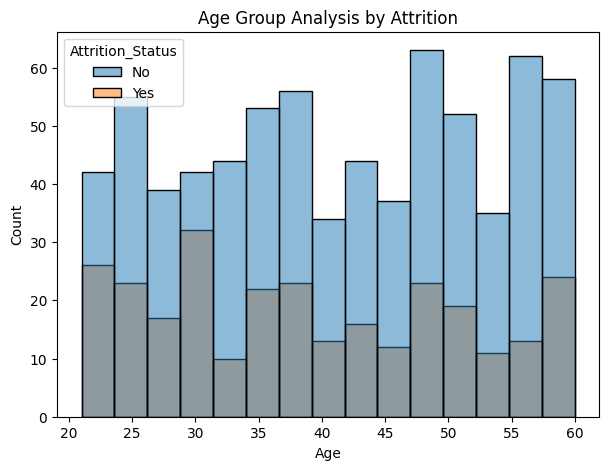

In [15]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x='Age', hue='Attrition_Status', bins=15)
plt.title('Age Group Analysis by Attrition')
plt.show()

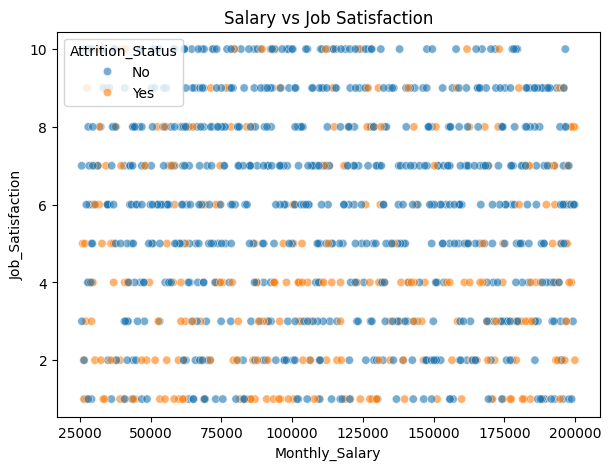

In [16]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='Monthly_Salary', y='Job_Satisfaction', hue='Attrition_Status', data=df, alpha=0.6)
plt.title('Salary vs Job Satisfaction')
plt.show()

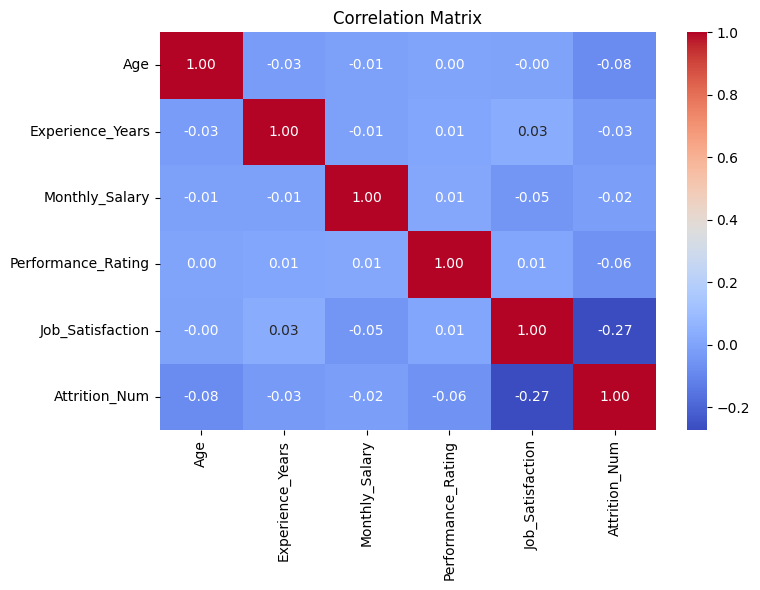

In [17]:
df['Attrition_Num'] = df['Attrition_Status'].map({'Yes': 1, 'No': 0})
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Age', 'Experience_Years', 'Monthly_Salary', 'Performance_Rating', 'Job_Satisfaction', 'Attrition_Num']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()